<a href="https://colab.research.google.com/github/DeepanshuSharma1607/house-price_and_average_happy_life_prediction/blob/main/notebook474ddf25d3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
arjunyadav99_indian_agricultural_mandi_prices_20232025_path = kagglehub.dataset_download('arjunyadav99/indian-agricultural-mandi-prices-20232025')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arjunyadav99/indian-agricultural-mandi-prices-20232025/Agriculture_price_dataset.csv


In [ ]:
df=pd.read_csv("/kaggle/input/datasets/arjunyadav99/indian-agricultural-mandi-prices-20232025/Agriculture_price_dataset.csv")

In [ ]:
df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


In [ ]:
df.shape

(737392, 10)

In [ ]:
df.tail()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
737387,Tamilnadu,namakkal,Kumarapalayam(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3000.0,3500.0,3500.0,6/11/2025
737388,Orissa,dhenkanal,Kamakhyanagar,Potato,Potato,Non-FAQ,1900.0,2200.0,2000.0,6/11/2025
737389,Tamilnadu,dindigul,Vedasanthur(Uzhavar Sandhai ),Potato,(Red Nanital),Local,3500.0,4000.0,4000.0,6/11/2025
737390,Tamilnadu,virudhunagar,Virudhunagar(Uzhavar Sandhai ),Onion,Bellary,Local,2800.0,3000.0,3000.0,6/11/2025
737391,Haryana,yamuna nagar,Chhachrauli,Onion,Onion,FAQ,1500.0,3000.0,3000.0,6/11/2025


In [ ]:
def unique_(x):
    print(df[x].nunique(),' - > ',df[x].unique())
    print("="*70)

In [ ]:
df['Price Date'] = pd.to_datetime(df['Price Date'])
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month

In [ ]:
def preprocess(s):
    return str(s).lower().strip().replace(' ','_')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737392 entries, 0 to 737391
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   STATE          737392 non-null  object        
 1   District Name  737392 non-null  object        
 2   Market Name    737392 non-null  object        
 3   Commodity      737392 non-null  object        
 4   Variety        737392 non-null  object        
 5   Grade          737392 non-null  object        
 6   Min_Price      737392 non-null  float64       
 7   Max_Price      737392 non-null  float64       
 8   Modal_Price    737392 non-null  float64       
 9   Price Date     737392 non-null  datetime64[ns]
 10  Year           737392 non-null  int32         
 11  Month          737392 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), object(6)
memory usage: 61.9+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
import pandas as pd

df['STATE'] = df['STATE'].str.lower().str.strip()

STATE_MAP = {
    ' punjab'               : 'punjab',

    'tamilnadu'             : 'tamil_nadu',
    'tamil nadu'            : 'tamil_nadu',

    'chattisgarh'           : 'chhattisgarh',

    'jammu & kashmir'       : 'jammu_and_kashmir',
    'jammu and kashmir'     : 'jammu_and_kashmir',

    'uttrakhand'            : 'uttarakhand',

    'gao'                   : 'goa',

    'maharashtra'           : 'maharashtra',
    'uttar pradesh'         : 'uttar_pradesh',
    'rajasthan'             : 'rajasthan',
    'haryana'               : 'haryana',
    'west bengal'           : 'west_bengal',
    'himachal pradesh'      : 'himachal_pradesh',
    'gujarat'               : 'gujarat',
    'meghalaya'             : 'meghalaya',
    'madhya pradesh'        : 'madhya_pradesh',
    'andhra pradesh'        : 'andhra_pradesh',
    'kerala'                : 'kerala',
    'nagaland'              : 'nagaland',
    'orissa'                : 'odisha',
    'karnataka'             : 'karnataka',
    'assam'                 : 'assam',
    'punjab'                : 'punjab',
    'delhi'                 : 'delhi',
    'bihar'                 : 'bihar',
    'chandigarh'            : 'chandigarh',
    'manipur'               : 'manipur',
    'tripura'               : 'tripura',
}

df['STATE'] = df['STATE'].replace(STATE_MAP)

known_states = set(STATE_MAP.values())
unknown = df.loc[~df['STATE'].isin(known_states), 'STATE'].unique()

if len(unknown):
    print("  Unmapped STATE values — add them to STATE_MAP:")
    for s in sorted(unknown):
        print(f"    '{s}'")
else:
    print("  All STATE values mapped cleanly.")

print(f"\nUnique states after cleaning: {df['STATE'].nunique()}")
print(df['STATE'].value_counts().to_string())

for col in ['District Name', 'Market Name']:
    df[col] = (
        df[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', '_', regex=True)
    )

print("\nRow count before / after:", len(df))
print("Null STATEs:", df['STATE'].isna().sum())

  All STATE values mapped cleanly.

Unique states after cleaning: 26
STATE
uttar_pradesh        188094
tamil_nadu            66628
haryana               63222
madhya_pradesh        55901
west_bengal           53927
maharashtra           51816
kerala                45605
punjab                44792
rajasthan             35785
gujarat               26652
himachal_pradesh      22837
odisha                20633
karnataka             14391
bihar                 12454
andhra_pradesh         9616
jammu_and_kashmir      6225
chhattisgarh           4853
assam                  4099
delhi                  3713
nagaland               3012
manipur                1317
chandigarh              949
meghalaya               810
uttarakhand              46
tripura                  11
goa                       4

Row count before / after: 737392
Null STATEs: 0


In [ ]:
ls=['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety',
       'Grade']
for i in ls:
    print(i)
    unique_(i)
    print('\n')
    df[i]=df[i].apply(preprocess)

STATE
26  - >  ['maharashtra' 'uttar_pradesh' 'rajasthan' 'haryana' 'west_bengal'
 'himachal_pradesh' 'gujarat' 'meghalaya' 'madhya_pradesh'
 'andhra_pradesh' 'kerala' 'nagaland' 'odisha' 'karnataka' 'assam'
 'punjab' 'jammu_and_kashmir' 'delhi' 'chhattisgarh' 'bihar' 'uttarakhand'
 'chandigarh' 'manipur' 'tamil_nadu' 'tripura' 'goa']


District Name
373  - >  ['nashik' 'satara' 'mainpuri' 'chittorgarh' 'pratapgarh' 'bharatpur'
 'ambala' 'birbhum' 'mandi' 'sambhal' 'panipat' 'bhavnagar' 'bareilly'
 'kaithal' 'kangra' 'west_garo_hills' 'rajgarh' 'sagar' 'nalgonda' 'anand'
 'ernakulam' 'satna' 'mandla' 'patan' 'amethi' 'sonipat' 'bulandshahar'
 'jhabua' 'mokokchung' 'una' 'thiruvananthapuram' 'hamirpur' 'nayagarh'
 'ahmednagar' 'surat' 'dhule' 'yamuna_nagar' 'jind' 'jaunpur' 'bangalore'
 'etawah' 'vidisha' 'lakhimpur' 'nadia' 'amreli' 'tikamgarh' 'mirzapur'
 'kurukshetra' 'ghazipur' 'ludhiana' 'deoria' 'kendrapara' 'bhind'
 'kurnool' 'fatehabad' 'bhopal' 'hanumangarh' 'kullu' 'porbandar'

In [ ]:
X_train=df[df['Year'].isin([2023,2024])].copy()
X_test=df[df['Year']==2025].copy()

In [ ]:
market_baseline = (
    X_train
    .groupby(['Market Name', 'Commodity'])['Modal_Price']
    .mean()
    .rename('Market_Commodity_Baseline')
)

# State-level baseline
state_baseline = (
    X_train
    .groupby(['STATE', 'Commodity'])['Modal_Price']
    .mean()
    .rename('State_Commodity_Baseline')
)

In [ ]:
def attach_baselines(df_, market_bl, state_bl):
    df_ = df_.join(market_bl, on=['Market Name', 'Commodity'])
    df_ = df_.join(state_bl,  on=['STATE', 'Commodity'])
    return df_

X_train = attach_baselines(X_train, market_baseline, state_baseline)
X_test  = attach_baselines(X_test,  market_baseline, state_baseline)

In [ ]:
grand_mean = X_train['Modal_Price'].mean()
X_train[['Market_Commodity_Baseline', 'State_Commodity_Baseline']] = \
    X_train[['Market_Commodity_Baseline', 'State_Commodity_Baseline']].fillna(grand_mean)
X_test[['Market_Commodity_Baseline', 'State_Commodity_Baseline']] = \
    X_test[['Market_Commodity_Baseline', 'State_Commodity_Baseline']].fillna(grand_mean)

In [ ]:
combined = pd.concat([X_train, X_test]).sort_values(['Market Name', 'Commodity', 'Price Date'])

grp = combined.groupby(['Market Name', 'Commodity'])['Modal_Price']

for lag in [1, 3, 7, 14, 30]:
    combined[f'Lag_{lag}'] = grp.shift(lag)

for window in [7, 14, 30]:
    combined[f'Roll_mean_{window}'] = grp.transform(lambda x: x.rolling(window).mean())
    combined[f'Roll_std_{window}']  = grp.transform(lambda x: x.rolling(window).std())

In [ ]:
train = combined[combined['Year'].isin([2023, 2024])].copy()
test  = combined[combined['Year'] == 2025].copy()

In [ ]:
df['Market_Commodity_Baseline'] = df.groupby(['Market Name', 'Commodity'])['Modal_Price'].transform('mean')
df['State_Commodity_Baseline'] = df.groupby(['STATE', 'Commodity'])['Modal_Price'].transform('mean')

In [ ]:
train = train.dropna(subset=[f'Lag_{l}' for l in [1,3,7,14,30]])
for col in [c for c in test.columns if c.startswith('Lag_') or c.startswith('Roll_')]:
    test[col] = test[col].fillna(test['Market_Commodity_Baseline'])

In [ ]:
drop_cols = ['Min_Price', 'Max_Price', 'Modal_Price', 'Price Date']
cat_features = ['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade']

x_train = train.drop(columns=drop_cols)
y_train = train['Modal_Price']
x_test  = test.drop(columns=drop_cols)
y_test  = test['Modal_Price']

print(f"Train shape: {x_train.shape}")

Train shape: (486420, 21)


In [ ]:
from catboost import CatBoostRegressor
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    cat_features=cat_features,
    early_stopping_rounds=100,
    eval_metric='MAE',
    verbose=200
)

In [ ]:
val_cutoff = pd.Timestamp('2024-10-01')
val_mask   = train['Price Date'] >= val_cutoff

x_val = x_train[val_mask]
y_val = y_train[val_mask]
x_tr  = x_train[~val_mask]
y_tr  = y_train[~val_mask]

model.fit(x_tr, y_tr, eval_set=(x_val, y_val), use_best_model=True)

0:	learn: 952.4693108	test: 1614.9957944	best: 1614.9957944 (0)	total: 380ms	remaining: 12m 39s
200:	learn: 155.2639285	test: 228.7694775	best: 228.2691292 (198)	total: 1m 17s	remaining: 11m 34s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 225.8111213
bestIteration = 239

Shrink model to first 240 iterations.


CatBoostRegressor(cat_features=['STATE', 'District Name', 'Market Name', 'Commodity', 'Variety', 'Grade'], depth=8, early_stopping_rounds=100, eval_metric='MAE', iterations=2000, l2_leaf_reg=3, learning_rate=0.05, loss_function='RMSE', verbose=200)

In [ ]:
preds = model.predict(x_test)
mae   = mean_absolute_error(y_test, preds)
rmse  = np.sqrt(mean_squared_error(y_test, preds))
r2    = r2_score(y_test, preds)
mape  = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"\nMAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


MAE:  194.34
RMSE: 1135.12
R²:   0.6398
MAPE: 11.05%


In [ ]:
from sklearn.metrics import mean_absolute_error
preds = model.predict(x_test)
print(f"MAE on 2025 data: {mean_absolute_error(y_test, preds):.2f}")

MAE on 2025 data: 194.34


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

MAE: 194.34
RMSE: 1135.12
R² Score: 0.6398
MAPE: 11.05%


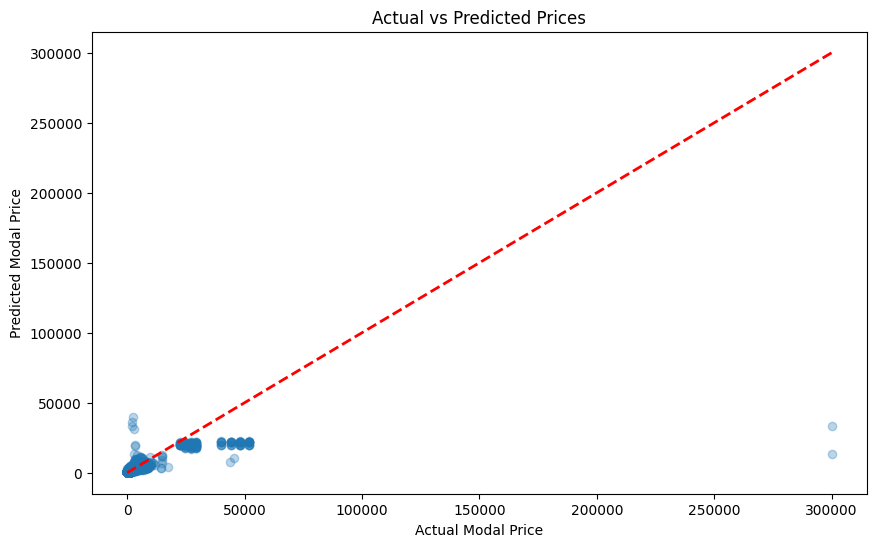

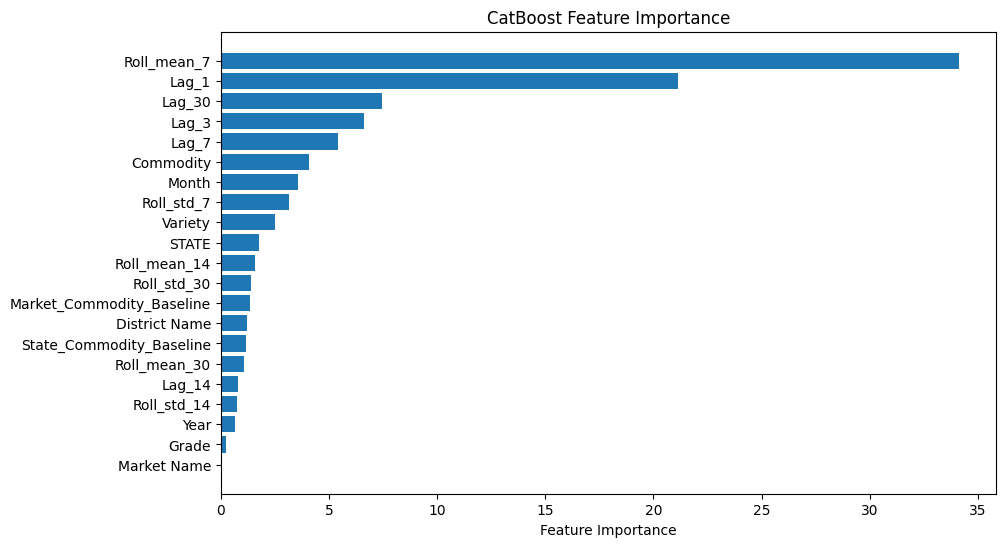

In [ ]:
# Plot 1: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Modal Price')
plt.ylabel('Predicted Modal Price')
plt.title('Actual vs Predicted Prices')
plt.savefig('actual_vs_predicted.png')

# Plot 2: Feature Importance
feature_importance = model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_train.columns)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('CatBoost Feature Importance')
plt.savefig('feature_importance.png')

In [ ]:
new_data = pd.DataFrame({
    'STATE': ['uttar_pradesh'],      # must exist
    'District Name': ['bareilly'],   # must exist
    'Market Name': ['bareilly'],     # EXACT match
    'Commodity': ['potato'],          # exists
    'Variety': ['other'],            # safer than 'local'
    'Grade': ['faq'],                # exists
    'Price Date': ['2027-06-12']
})

In [ ]:
new_data['Price Date'] = pd.to_datetime(new_data['Price Date'])
new_data['Year'] = new_data['Price Date'].dt.year
new_data['Month'] = new_data['Price Date'].dt.month

def preprocess(s):
    return str(s).lower().strip().replace(' ','_')

for col in ['STATE','District Name','Market Name','Commodity','Variety','Grade']:
    new_data[col] = new_data[col].apply(preprocess)

In [ ]:
new_data = new_data.join(market_baseline, on=['Market Name','Commodity'])
new_data = new_data.join(state_baseline, on=['STATE','Commodity'])

new_data[['Market_Commodity_Baseline','State_Commodity_Baseline']] = \
    new_data[['Market_Commodity_Baseline','State_Commodity_Baseline']].fillna(grand_mean)

In [ ]:
new_data

,STATE,District Name,Market Name,Commodity,Variety,Grade,Price Date,Year,Month,Market_Commodity_Baseline,State_Commodity_Baseline
0,uttar_pradesh,bareilly,bareilly,potato,other,faq,2027-06-12,2027,6,1419.931099,1432.905505


In [ ]:
history = df[
    (df['Market Name']=='bareilly') &
    (df['Commodity']=='potato')
].sort_values('Price Date')

In [ ]:
history

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date,Year,Month,Market_Commodity_Baseline,State_Commodity_Baseline
241,uttar_pradesh,bareilly,bareilly,potato,desi,faq,900.0,950.0,925.0,2023-06-06,2023,6,1284.091811,1357.411947
2219,uttar_pradesh,bareilly,bareilly,potato,desi,faq,900.0,950.0,920.0,2023-06-07,2023,6,1284.091811,1357.411947
4516,uttar_pradesh,bareilly,bareilly,potato,desi,faq,900.0,950.0,925.0,2023-06-08,2023,6,1284.091811,1357.411947
5745,uttar_pradesh,bareilly,bareilly,potato,desi,faq,900.0,925.0,915.0,2023-06-09,2023,6,1284.091811,1357.411947
8117,uttar_pradesh,bareilly,bareilly,potato,desi,faq,890.0,925.0,915.0,2023-06-10,2023,6,1284.091811,1357.411947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
734881,uttar_pradesh,bareilly,bareilly,potato,potato,faq,1025.0,1100.0,1050.0,2025-06-09,2025,6,1284.091811,1357.411947
736474,uttar_pradesh,bareilly,bareilly,potato,potato,non-faq,935.0,975.0,950.0,2025-06-10,2025,6,1284.091811,1357.411947
736510,uttar_pradesh,bareilly,bareilly,potato,potato,faq,1025.0,1075.0,1040.0,2025-06-10,2025,6,1284.091811,1357.411947
736560,uttar_pradesh,bareilly,bareilly,potato,potato,faq,1025.0,1075.0,1050.0,2025-06-11,2025,6,1284.091811,1357.411947


In [ ]:
new_data['Lag_1']  = history['Modal_Price'].iloc[-1]
new_data['Lag_3']  = history['Modal_Price'].iloc[-3]
new_data['Lag_7']  = history['Modal_Price'].iloc[-7]
new_data['Lag_14'] = history['Modal_Price'].iloc[-14]
new_data['Lag_30'] = history['Modal_Price'].iloc[-30]

In [ ]:
new_data

,STATE,District Name,Market Name,Commodity,Variety,Grade,Price Date,Year,Month,Market_Commodity_Baseline,State_Commodity_Baseline,Lag_1,Lag_3,Lag_7,Lag_14,Lag_30
0,uttar_pradesh,bareilly,bareilly,potato,other,faq,2027-06-12,2027,6,1419.931099,1432.905505,960.0,1040.0,975.0,1040.0,1080.0


In [ ]:
new_data['Roll_mean_7']  = history['Modal_Price'].iloc[-7:].mean()
new_data['Roll_std_7']   = history['Modal_Price'].iloc[-7:].std()

new_data['Roll_mean_14'] = history['Modal_Price'].iloc[-14:].mean()
new_data['Roll_std_14']  = history['Modal_Price'].iloc[-14:].std()

new_data['Roll_mean_30'] = history['Modal_Price'].iloc[-30:].mean()
new_data['Roll_std_30']  = history['Modal_Price'].iloc[-30:].std()

In [ ]:
new_data

,STATE,District Name,Market Name,Commodity,Variety,Grade,Price Date,Year,Month,Market_Commodity_Baseline,...,Lag_3,Lag_7,Lag_14,Lag_30,Roll_mean_7,Roll_std_7,Roll_mean_14,Roll_std_14,Roll_mean_30,Roll_std_30
0,uttar_pradesh,bareilly,bareilly,potato,other,faq,2027-06-12,2027,6,1419.931099,...,1040.0,975.0,1040.0,1080.0,997.857143,46.355253,1007.142857,43.266361,1016.333333,49.583321


In [ ]:
drop_cols = ['Price Date']
x_new = new_data.drop(columns=drop_cols)

In [ ]:
prediction = model.predict(x_new)
print("Predicted Price:", prediction[0], "per 100kg")

Predicted Price: 1008.109764135643 per 100kg


In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(market_baseline, "market_baseline.pkl")
joblib.dump(state_baseline, "state_baseline.pkl")
joblib.dump(grand_mean, "grand_mean.pkl")

['grand_mean.pkl']